In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as nps


/tmp/ipython-input-3717608317.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNet(


Using layer 56: conv_dw_9_bn
Step 0, loss = 2.346
Step 50, loss = 8.824
Step 100, loss = 9.853
Step 150, loss = 10.367
Step 200, loss = 10.657
Step 250, loss = 10.848
Step 300, loss = 11.023
Step 350, loss = 11.132


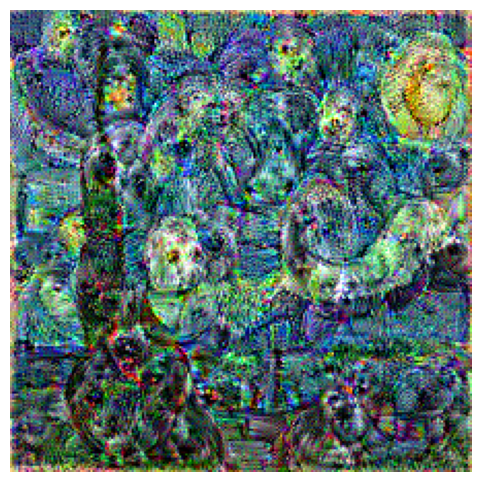

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import Input
from tensorflow.keras.models import Model


# ---- Loss as a FUNCTION ----
def squared_sum_loss(activations):
    return tf.reduce_mean(tf.square(activations))


# ---- Load & preprocess image ----
img = Image.open("Image.jpeg").resize((224, 224))
img = np.array(img).astype(np.float32)
img = tf.keras.applications.mobilenet.preprocess_input(img)

image = tf.Variable(img[None, ...], dtype=tf.float32)


# ---- Model setup ----
input_tensor = Input(shape=(224, 224, 3))
base_model = tf.keras.applications.MobileNet(
    input_tensor=input_tensor,
    include_top=False
)

dream_layer_index = 56
dream_model = Model(
    input_tensor,
    base_model.layers[dream_layer_index].output
)

print(f"Using layer {dream_layer_index}: {base_model.layers[dream_layer_index].name}")


# ---- DeepDream step ----
def dream_step(image, step_size):
    with tf.GradientTape() as tape:
        tape.watch(image)
        output = dream_model(image)
        loss = squared_sum_loss(output)

    gradients = tape.gradient(loss, image)
    gradients /= tf.math.reduce_std(gradients) + 1e-8

    image.assign_add(step_size * gradients)
    image.assign(tf.clip_by_value(image, -1.0, 1.0))

    return loss


# ---- Run optimization ----
steps = 400
step_size = 0.02

for step in range(steps):
    loss = dream_step(image, step_size)
    if step % 50 == 0:
        print(f"Step {step}, loss = {loss.numpy():.3f}")


# ---- Deprocess & visualize ----
def deprocess(img):
    img = img[0]
    img = (img + 1.0) * 127.5
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().astype(np.uint8)

result = deprocess(image)

plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.axis("off")
plt.show()
